# Laboratorio 2 - Problema 2

## Operaciones entre imágenes

### Objetivo

Implementar una función que permita realizar operaciones aritméticas y lógicas entre dos imágenes. Las operaciones aritméticas se aplicarán sobre imágenes a color, mientras que las operaciones lógicas se realizarán sobre imágenes previamente convertidas a escala de grises y binarizadas.

## Fundamento teórico

Las operaciones entre imágenes constituyen una herramienta fundamental del procesamiento digital de imágenes.

### Operaciones aritméticas

- **Suma:** incrementa la intensidad de los píxeles al combinar dos imágenes.
- **Resta:** permite identificar diferencias entre imágenes.

### Operaciones lógicas

Estas operaciones trabajan sobre imágenes binarias.

- **AND:** conserva únicamente los píxeles blancos presentes en ambas imágenes.
- **OR:** conserva los píxeles blancos presentes en cualquiera de las imágenes.
- **XOR:** conserva únicamente los píxeles que son diferentes entre ambas imágenes.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Carga de las imágenes

Se cargan dos imágenes desde el directorio del proyecto. Posteriormente se convierten al espacio RGB para facilitar su visualización con Matplotlib.

In [2]:
ruta1 = "../Imagenes lab/2.jpg"
ruta2 = "../Imagenes lab/3.jpg"

imagen1 = cv2.imread(ruta1)
imagen2 = cv2.imread(ruta2)

if imagen1 is None or imagen2 is None:
    raise Exception("No fue posible cargar una de las imágenes.")

In [3]:
altura = min(imagen1.shape[0], imagen2.shape[0])
ancho = min(imagen1.shape[1], imagen2.shape[1])

imagen1 = cv2.resize(imagen1, (ancho, altura))
imagen2 = cv2.resize(imagen2, (ancho, altura))

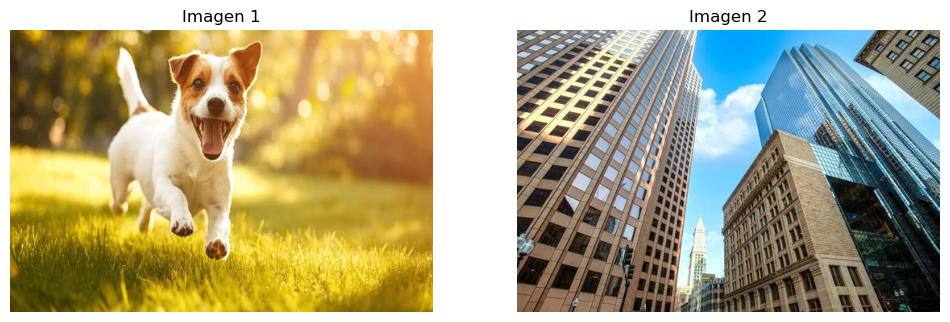

In [4]:
img1 = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(imagen2, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(img1)
ax[0].set_title("Imagen 1")
ax[0].axis("off")

ax[1].imshow(img2)
ax[1].set_title("Imagen 2")
ax[1].axis("off")

plt.show()

## Implementación de las operaciones

Se implementa una función que realiza las operaciones solicitadas utilizando las funciones de OpenCV.

In [5]:
def operaciones(imagen1, imagen2):

    suma = cv2.add(imagen1, imagen2)

    resta = cv2.subtract(imagen1, imagen2)

    gris1 = cv2.cvtColor(imagen1, cv2.COLOR_BGR2GRAY)
    gris2 = cv2.cvtColor(imagen2, cv2.COLOR_BGR2GRAY)

    _, bin1 = cv2.threshold(gris1,127,255,cv2.THRESH_BINARY)
    _, bin2 = cv2.threshold(gris2,127,255,cv2.THRESH_BINARY)

    AND = cv2.bitwise_and(bin1, bin2)
    OR = cv2.bitwise_or(bin1, bin2)
    XOR = cv2.bitwise_xor(bin1, bin2)

    return suma, resta, bin1, bin2, AND, OR, XOR

In [6]:
suma, resta, bin1, bin2, AND, OR, XOR = operaciones(imagen1, imagen2)

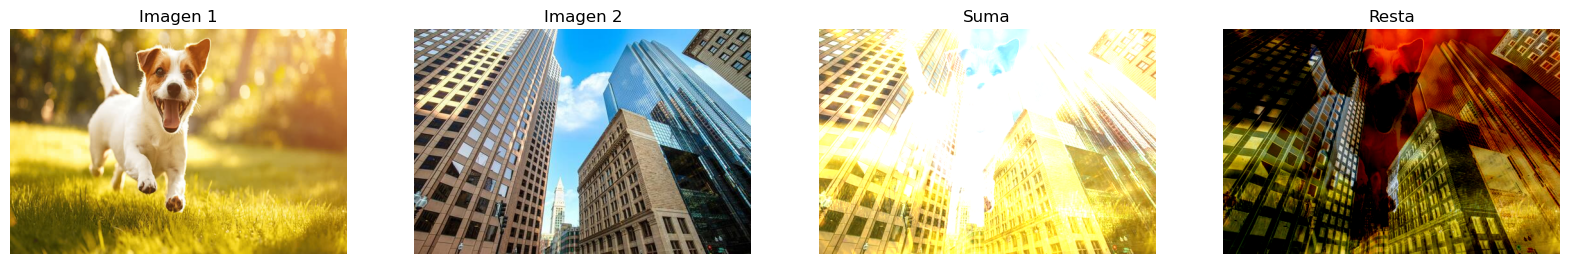

In [7]:
fig, ax = plt.subplots(1,4, figsize=(20,6))

ax[0].imshow(img1)
ax[0].set_title("Imagen 1")

ax[1].imshow(img2)
ax[1].set_title("Imagen 2")

ax[2].imshow(cv2.cvtColor(suma, cv2.COLOR_BGR2RGB))
ax[2].set_title("Suma")

ax[3].imshow(cv2.cvtColor(resta, cv2.COLOR_BGR2RGB))
ax[3].set_title("Resta")

for a in ax:
    a.axis("off")

plt.show()

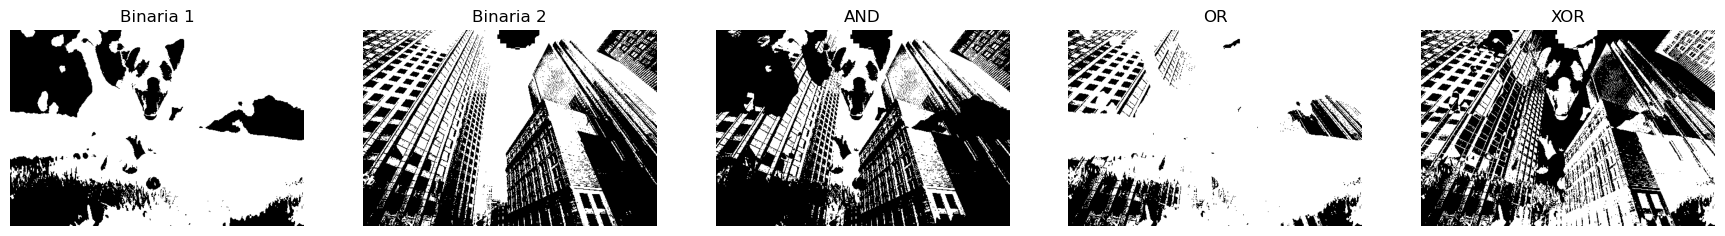

In [8]:
fig, ax = plt.subplots(1,5, figsize=(22,6))

ax[0].imshow(bin1,cmap="gray")
ax[0].set_title("Binaria 1")

ax[1].imshow(bin2,cmap="gray")
ax[1].set_title("Binaria 2")

ax[2].imshow(AND,cmap="gray")
ax[2].set_title("AND")

ax[3].imshow(OR,cmap="gray")
ax[3].set_title("OR")

ax[4].imshow(XOR,cmap="gray")
ax[4].set_title("XOR")

for a in ax:
    a.axis("off")

plt.show()

## Análisis de resultados

Las operaciones aritméticas modifican directamente los valores de intensidad de los píxeles, permitiendo combinar o resaltar diferencias entre imágenes.

Por otra parte, las operaciones lógicas trabajan sobre imágenes binarias. La operación **AND** conserva únicamente las regiones comunes, **OR** une las regiones presentes en cualquiera de las imágenes y **XOR** resalta exclusivamente las diferencias entre ambas.

Estas operaciones son ampliamente utilizadas en tareas de segmentación, detección de objetos y análisis de imágenes.

## Conclusiones

- OpenCV proporciona funciones optimizadas para realizar operaciones aritméticas y lógicas entre imágenes.
- Las operaciones lógicas requieren trabajar sobre imágenes binarias para obtener resultados coherentes.
- La combinación de estas operaciones permite desarrollar algoritmos de segmentación y comparación de imágenes utilizados en aplicaciones de visión artificial.